In [1]:
import sksurv #scikit-survival
import pandas as pd
import numpy as np
import sys
import os
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv
from sksurv.compare import compare_survival

sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [2]:
pp = Preprocessor()
plots = Plots()
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)

    

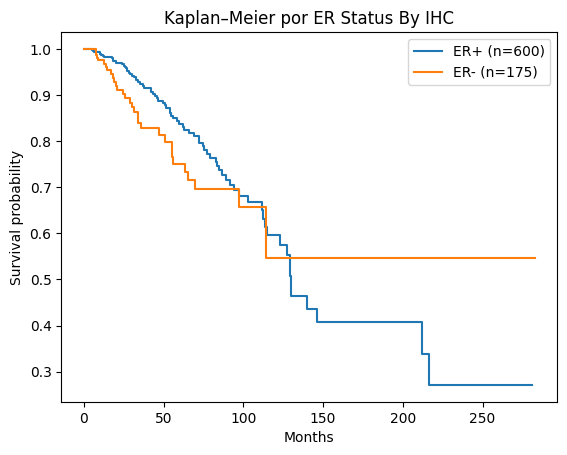

Log-rank: chi2=1.638, p=0.2007


In [3]:

km_df = plots.plot_kaplan_meier_binary(df_clinical_keep, time_col="Overall Survival (Months)", status_col="Overall Survival Status",marker_col="ER Status By IHC")

In [4]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")



Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)


In [5]:

clean_df = pp.elimnation_zeros(df_mRNA_transformed, "Hugo_Symbol")
ESR1 = clean_df[clean_df["Hugo_Symbol"] == "ESR1"]
AURKA = clean_df[clean_df["Hugo_Symbol"] == "AURKA"]


pacientes = ESR1.iloc[:, 2:]

expr = pacientes.iloc[0]

threshold = np.median(expr)


low_bound = list()
upper_bound = list()

for patient_id ,value in expr.items():
   if value < threshold:
      low_bound.append(patient_id)
   else:
      upper_bound.append(patient_id)

ESR1_low = ESR1.loc[:,  low_bound]
ESR1_Big = ESR1.loc[: , upper_bound]


Max of zeros per row in the dataset: 4575
Avg of zeros per row in the dataset: 2911.273838630807
Median of zeros per row in the dataset: 2866.5
Min of zeros per row in the dataset: 0
After the 0 elimination: 454


In [ ]:
def gene_to_long(df_mrna: pd.DataFrame, gene: str) -> pd.DataFrame:
    
    row = df_mrna.loc[df_mrna["Hugo_Symbol"].eq(gene)]
    if row.empty:
        raise ValueError(f"No existe {gene} en df_mrna")

    sample_cols = [c for c in df_mrna.columns if c not in ["Hugo_Symbol", "Entrez_Gene_Id"]]
    row = row[["Hugo_Symbol"] + sample_cols].iloc[0]

    out = (
        row.drop(labels=["Hugo_Symbol"])
           .rename("expression")
           .to_frame()
           .reset_index()
           .rename(columns={"index": "Sample ID"})
    )
    out["Hugo_Symbol"] = gene
    return out

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv
from sksurv.compare import compare_survival

def plot_km_from_mrna_and_clinical(df_mrna: pd.DataFrame,
                                  df_clin: pd.DataFrame,
                                  time_col: str,
                                  status_col: str,
                                  gene: str) -> pd.DataFrame:

    df_esr1 = gene_to_long(df_mrna, gene)

    df = df_esr1.merge(df_clin, on="Sample ID", how="inner")

    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    status = df[status_col].astype(str).str.strip()
    df["event"] = status.str.contains("DECEASED", na=False)

    df["expression"] = pd.to_numeric(df["expression"], errors="coerce")
    df = df.dropna(subset=["expression", time_col, "event"])

    thr = float(df["expression"].median())
    df["group"] = np.where(df["expression"] < thr, f"{gene}-", f"{gene}+")
    print("threshold =", thr)

    plt.figure()
    for group in [f"{gene}+", f"{gene}-"]:
        sub = df[df["group"] == group]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub[time_col].to_numpy(dtype=float)
        t, s = kaplan_meier_estimator(event, time)
        plt.step(t, s, where="post", label=f"{group} (n={len(sub)})")
    plt.xlabel("Months")
    plt.ylabel("Survival probability")
    plt.title(f"Kaplan–Meier por {gene} (mediana)")
    plt.legend()
    plt.show()

    y = Surv.from_arrays(df["event"].to_numpy(bool), df[time_col].to_numpy(float))
    chisq, p_value = compare_survival(y, df["group"].to_numpy())
    print(f"Log-rank: chi2={chisq:.3f}, p={p_value:.4g}")

    return df

threshold = 6482.9679


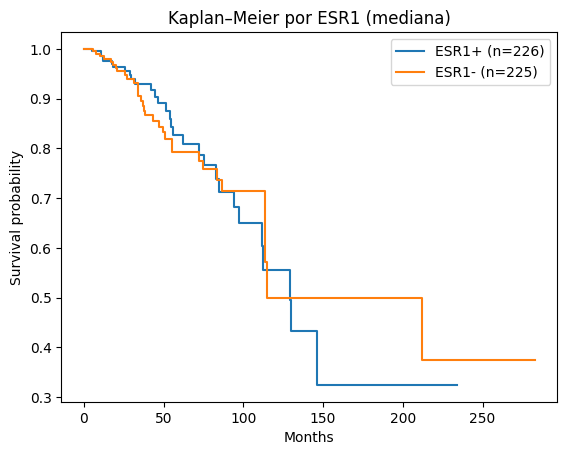

Log-rank: chi2=0.003, p=0.9586


In [ ]:
km_esr1 = plot_km_from_mrna_and_clinical(
    df_mrna=clean_df,              
    df_clin=df_clinical_keep,      
    time_col="Overall Survival (Months)",
    status_col="Overall Survival Status",
    gene="ESR1"
)

threshold = 428.9373


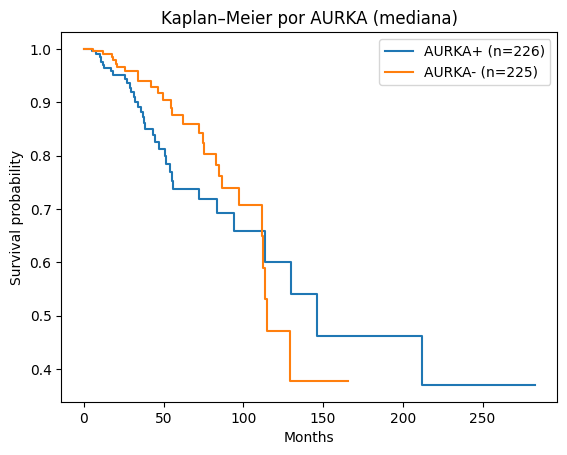

Log-rank: chi2=1.474, p=0.2247


In [16]:
km_esr1 = plot_km_from_mrna_and_clinical(
    df_mrna=clean_df,              
    df_clin=df_clinical_keep,      
    time_col="Overall Survival (Months)",
    status_col="Overall Survival Status",
    gene="AURKA"
)